In [2]:
# ============================================================
# ClimGuard - Exploration des données de Douala (EDA)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Bibliothèques chargées avec succès")

✅ Bibliothèques chargées avec succès


In [3]:
# ============================================================
# CHARGEMENT DES DONNÉES
# ============================================================

# Données météo
df_weather = pd.read_csv('../data/raw/douala_weather_2010_2024.csv')
df_weather['date'] = pd.to_datetime(df_weather['date'])

# Données zones à risque
df_zones = pd.read_csv('../data/raw/douala_zones_risque.csv')

print("📊 DONNÉES MÉTÉO")
print(f"   → Nombre de jours : {len(df_weather)}")
print(f"   → Période : {df_weather['date'].min()} au {df_weather['date'].max()}")
print(f"   → Colonnes : {list(df_weather.columns)}")
print()
print("📊 DONNÉES ZONES À RISQUE")
print(f"   → Nombre de quartiers : {len(df_zones)}")
print(f"   → Colonnes : {list(df_zones.columns)}")
print()

# Aperçu des données météo
print("🔍 Aperçu données météo (5 premières lignes):")
df_weather.head()

📊 DONNÉES MÉTÉO
   → Nombre de jours : 5479
   → Période : 2010-01-01 00:00:00 au 2024-12-31 00:00:00
   → Colonnes : ['date', 'precipitation_sum', 'temperature_2m_max', 'temperature_2m_min', 'windspeed_10m_max', 'et0_fao_evapotranspiration']

📊 DONNÉES ZONES À RISQUE
   → Nombre de quartiers : 10
   → Colonnes : ['quartier', 'latitude', 'longitude', 'niveau_risque', 'score_risque', 'type_risque', 'population_exposee', 'description']

🔍 Aperçu données météo (5 premières lignes):


,date,precipitation_sum,temperature_2m_max,temperature_2m_min,windspeed_10m_max,et0_fao_evapotranspiration
0,2010-01-01,1.8,30.9,24.1,13.8,3.65
1,2010-01-02,1.3,31.4,24.2,11.3,3.96
2,2010-01-03,1.2,31.0,24.4,12.3,3.51
3,2010-01-04,1.5,30.7,24.2,12.5,3.65
4,2010-01-05,0.7,30.5,24.3,13.8,3.67


In [4]:
# ============================================================
# STATISTIQUES DESCRIPTIVES
# ============================================================

print("📈 STATISTIQUES MÉTÉO DE DOUALA (2010-2024)")
print("=" * 50)
stats = df_weather.describe()
print(stats)
print()

# Vérification des valeurs manquantes
print("❓ VALEURS MANQUANTES :")
print(df_weather.isnull().sum())

📈 STATISTIQUES MÉTÉO DE DOUALA (2010-2024)
                      date  precipitation_sum  temperature_2m_max  \
count                 5479        5479.000000         5479.000000   
mean   2017-07-02 00:00:00           8.261690           29.589560   
min    2010-01-01 00:00:00           0.000000           22.900000   
25%    2013-10-01 12:00:00           1.700000           28.200000   
50%    2017-07-02 00:00:00           4.700000           29.700000   
75%    2021-04-01 12:00:00          10.700000           31.000000   
max    2024-12-31 00:00:00         207.300000           36.700000   
std                    NaN          12.131232            2.079939   

       temperature_2m_min  windspeed_10m_max  et0_fao_evapotranspiration  
count         5479.000000        5479.000000                 5479.000000  
mean            23.507337          11.686914                    3.109212  
min             20.600000           3.700000                    0.440000  
25%             22.900000          

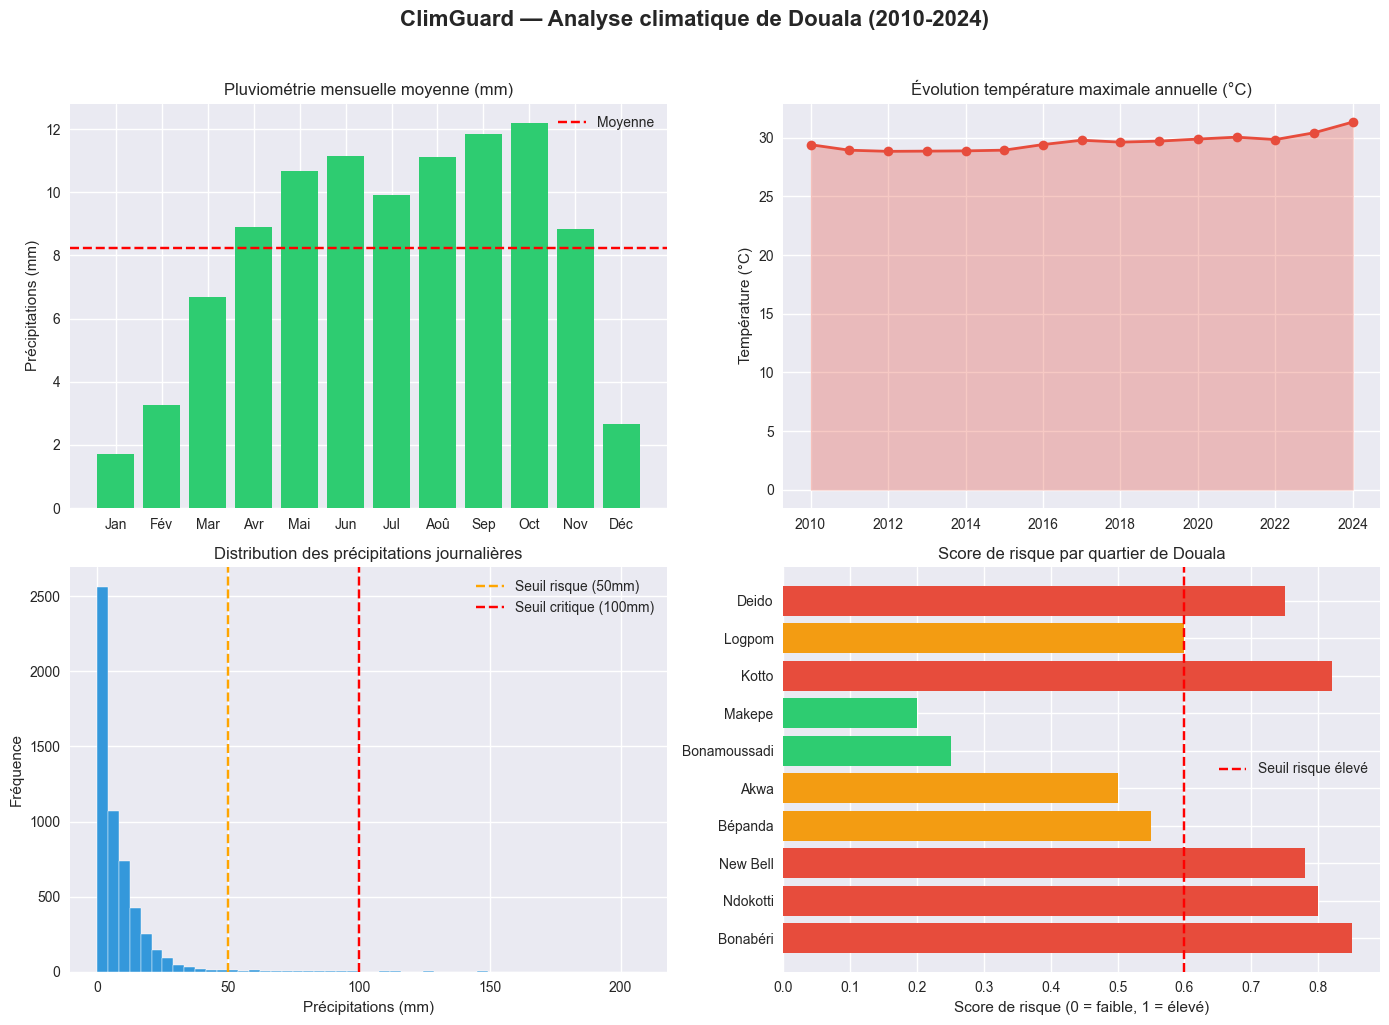

✅ Graphique sauvegardé dans data/processed/


In [5]:
# ============================================================
# VISUALISATION 1 — Pluviométrie annuelle à Douala
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ClimGuard — Analyse climatique de Douala (2010-2024)', 
             fontsize=16, fontweight='bold', y=1.02)

# Graphique 1 : Pluviométrie mensuelle moyenne
df_weather['mois'] = df_weather['date'].dt.month
pluie_mensuelle = df_weather.groupby('mois')['precipitation_sum'].mean()
mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun',
                'Jul','Aoû','Sep','Oct','Nov','Déc']

axes[0,0].bar(range(1,13), pluie_mensuelle.values, 
               color=['#e74c3c' if v > 150 else '#f39c12' 
                      if v > 80 else '#2ecc71' 
                      for v in pluie_mensuelle.values])
axes[0,0].set_xticks(range(1,13))
axes[0,0].set_xticklabels(mois_labels)
axes[0,0].set_title('Pluviométrie mensuelle moyenne (mm)')
axes[0,0].set_ylabel('Précipitations (mm)')
axes[0,0].axhline(y=pluie_mensuelle.mean(), color='red', 
                   linestyle='--', label='Moyenne')
axes[0,0].legend()

# Graphique 2 : Évolution température maximale
df_weather['annee'] = df_weather['date'].dt.year
temp_annuelle = df_weather.groupby('annee')['temperature_2m_max'].mean()

axes[0,1].plot(temp_annuelle.index, temp_annuelle.values, 
                marker='o', color='#e74c3c', linewidth=2)
axes[0,1].fill_between(temp_annuelle.index, temp_annuelle.values, 
                         alpha=0.3, color='#e74c3c')
axes[0,1].set_title('Évolution température maximale annuelle (°C)')
axes[0,1].set_ylabel('Température (°C)')

# Graphique 3 : Distribution des précipitations
axes[1,0].hist(df_weather['precipitation_sum'].dropna(), 
                bins=50, color='#3498db', edgecolor='white')
axes[1,0].set_title('Distribution des précipitations journalières')
axes[1,0].set_xlabel('Précipitations (mm)')
axes[1,0].set_ylabel('Fréquence')
axes[1,0].axvline(x=50, color='orange', linestyle='--', 
                   label='Seuil risque (50mm)')
axes[1,0].axvline(x=100, color='red', linestyle='--', 
                   label='Seuil critique (100mm)')
axes[1,0].legend()

# Graphique 4 : Zones à risque de Douala
couleurs = {'Élevé': '#e74c3c', 'Moyen': '#f39c12', 'Faible': '#2ecc71'}
couleurs_zones = df_zones['niveau_risque'].map(couleurs)

axes[1,1].barh(df_zones['quartier'], df_zones['score_risque'],
                color=couleurs_zones)
axes[1,1].set_title('Score de risque par quartier de Douala')
axes[1,1].set_xlabel('Score de risque (0 = faible, 1 = élevé)')
axes[1,1].axvline(x=0.6, color='red', linestyle='--', 
                   label='Seuil risque élevé')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../data/processed/analyse_climatique_douala.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé dans data/processed/")